![imagen](Airbnb.png)

# Exercise 2

To begin characterizing the various types of accommodations available on Airbnb in Amsterdam, the following points of interest are noted:

1. 50% of the listings on the platform primarily offer hotel rooms.

2. The vast majority of private rooms are priced between 4 and 129 euros. 

3. Houses and apartments have the highest review ratings on the platform. 

4. Houses and apartments have the widest range of rental prices.

5. The listings with the best price scores are houses, apartments, and hotel rooms.

# 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

# 2. Load data

In [2]:
data= pd.read_csv('listings_m-2-.csv', sep=',')
data.head()

,id,listing_url,scrape_id,last_scraped,name,description,neighborhood_overview,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2818,https://www.airbnb.com/rooms/2818,2.021040e+13,12/04/2021,Quiet Garden View Room & Super Fast WiFi,Quiet Garden View Room & Super Fast WiFi<br />...,"Indische Buurt (""Indies Neighborhood"") is a ne...",https://a0.muscache.com/pictures/10272854/8dcc...,3159,https://www.airbnb.com/users/show/3159,...,10.0,9.0,10.0,NaN,t,1,0,1,0,1.90
1,20168,https://www.airbnb.com/rooms/20168,2.021040e+13,12/04/2021,Studio with private bathroom in the centre 1,17th century Dutch townhouse in the heart of t...,Located just in between famous central canals....,https://a0.muscache.com/pictures/69979628/fd6a...,59484,https://www.airbnb.com/users/show/59484,...,10.0,10.0,9.0,0363 CBB3 2C10 0C2A 1E29,t,2,0,2,0,2.50
2,25428,https://www.airbnb.com/rooms/25428,2.021040e+13,11/04/2021,"Lovely, 1 bed apt in Ctr (w.lift) -3/20-6/20(f...",Lovely apt in Centre ( lift & fireplace) near ...,NaN,https://a0.muscache.com/pictures/138431/7079a9...,56142,https://www.airbnb.com/users/show/56142,...,10.0,10.0,10.0,NaN,f,2,2,0,0,0.13
3,27886,https://www.airbnb.com/rooms/27886,2.021040e+13,11/04/2021,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,...,10.0,10.0,10.0,0363 974D 4986 7411 88D8,t,1,0,1,0,1.94
4,28871,https://www.airbnb.com/rooms/28871,2.021040e+13,13/04/2021,Comfortable double room,<b>The space</b><br />In a monumental house ri...,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,...,10.0,10.0,10.0,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,2.59


In [3]:
data = data[['room_type','price', 'review_scores_rating','review_scores_value']]
data.head()

,room_type,price,review_scores_rating,review_scores_value
0,Private room,59,98.0,10.0
1,Private room,200,89.0,9.0
2,Entire home/apt,125,100.0,10.0
3,Private room,141,99.0,10.0
4,Private room,75,97.0,10.0


# 3. Hypothesis

#### 1. 50% of the listings on the platform primarily offer hotel rooms.

In [4]:
freq_table = data['room_type'].value_counts().reset_index()
freq_table.columns = ['room_type', 'count']
freq_table['frequency'] = (freq_table['count'] / freq_table['count'].sum()).round(4) * 100
freq_table['absolute_frequency'] = freq_table['count'].cumsum()
freq_table['cumulative_relative_frequency'] = freq_table['frequency'].cumsum().round(4) 
freq_table

,room_type,count,frequency,absolute_frequency,cumulative_relative_frequency
0,Entire home/apt,13896,77.96,13896,77.96
1,Private room,3756,21.07,17652,99.03
2,Hotel room,124,0.70,17776,99.73
3,Shared room,49,0.27,17825,100.00


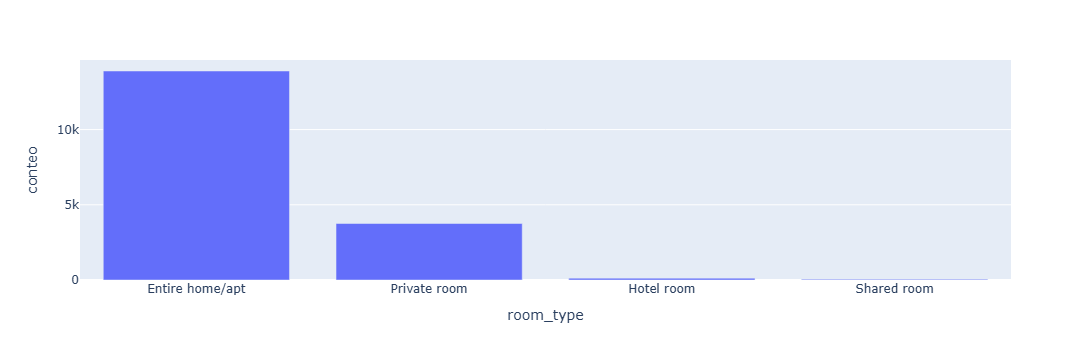

In [5]:
data_room_type = data['room_type'].value_counts().reset_index()
data_room_type.columns = ['room_type','conteo']
figura = px.bar(data_room_type, x='room_type', y='conteo')
figura.show()

#### The statement is false, hotel rooms represent only 0.7% of the total listings.

#### 2. The vast majority of private rooms are priced between 4 and 129 euros.

We need to filter the private rooms and the price from the dataset

In [6]:
private_rooms = data[data['room_type'] == 'Private room'][['room_type', 'price']]

In [7]:
price_range = private_rooms.loc[(private_rooms['price'] >= 4) & (private_rooms['price'] <= 129)] 
percentage = len(price_range) / len(private_rooms) * 100
print(percentage)

82.58785942492013


Use the .loc function to filter the rows where the price was >= 4 and <= 129 and create another dataset called “price_range,” then calculate the percentage of private rooms that fell within that price range

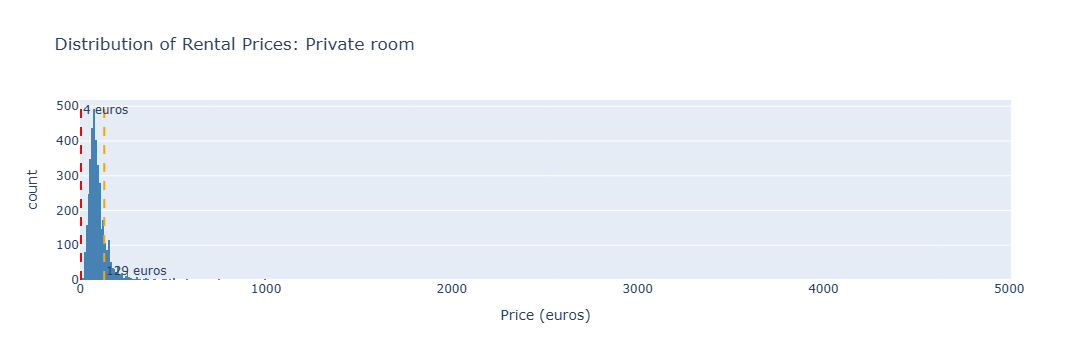

In [8]:
fig = px.histogram(private_rooms, x='price', nbins=500,
                   title='Distribution of Rental Prices: Private room',
                   labels={'price': 'Price (euros)'},
                   color_discrete_sequence=['steelblue'])

fig.add_vline(x=4, line_dash='dash', line_color='red', 
              annotation_text='4 euros')
fig.add_vline(x=129, line_dash='dash', line_color='orange', 
              annotation_text='129 euros',
             annotation_position='bottom right')

fig.show()

#### The statement is true: 82.58% of private rooms fall within the range of 4 to 129 euros.

#### 3. Houses and apartments have the highest review ratings on the platform.

In [9]:
review_by_room = data.groupby('room_type')['review_scores_rating'].agg(['mean', 'median', 'std']).reset_index()
review_by_room.columns = ['room_type', 'mean', 'median', 'std']
review_by_room

,room_type,mean,median,std
0,Entire home/apt,95.351802,97.0,6.931158
1,Hotel room,94.000000,95.0,4.811012
2,Private room,93.997754,96.0,8.105029
3,Shared room,94.022727,94.0,4.844026


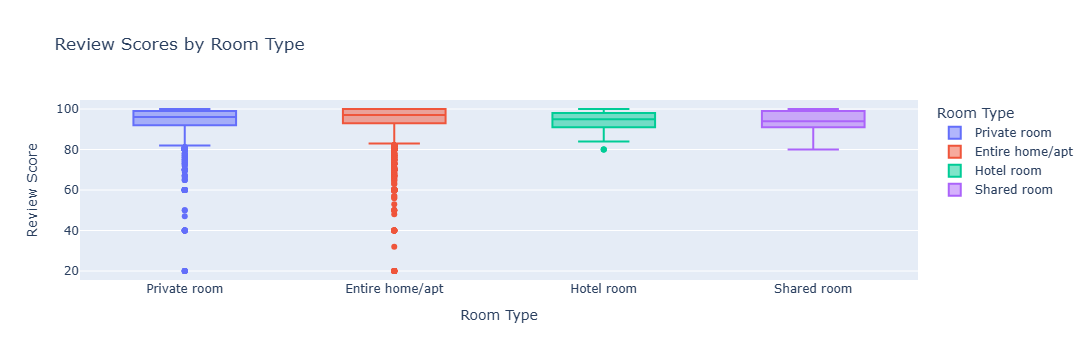

In [10]:
fig = px.box(data, x='room_type', y='review_scores_rating',
             title='Review Scores by Room Type',
             labels={'room_type': 'Room Type', 'review_scores_rating': 'Review Score'},
             color='room_type')
fig.show()

Although entire houses and apartments have the highest average score (95.35), the differences between all types of accommodations are minimal, as less than two points separate the highest average from the lowest. Furthermore, the dataset exhibits a significant bias, as entire houses and apartments account for 78% of the listings, compared to 21% for private rooms, with the remainder split between hotel rooms and shared rooms. The presence of outliers in both categories and the imbalance in the dataset suggest that this hypothesis is only partially supported.

#### 4. Houses and apartments have the widest range of rental prices.

We calculated the variance, interquartile range, coefficient of variation, and range to assess the dispersion of each type of accommodation

In [11]:
dispersion = data.groupby('room_type')['price'].agg(
    std='std',
    iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
    cv=lambda x: x.std() / x.mean() * 100,
    range=lambda x: x.max() - x.min()
).reset_index()
dispersion

,room_type,std,iqr,cv,range
0,Entire home/apt,160.081373,91.0,94.242190,7996
1,Hotel room,165.625230,133.5,122.575521,990
2,Private room,113.509545,50.0,114.681088,4991
3,Shared room,123.831223,55.0,122.013471,634


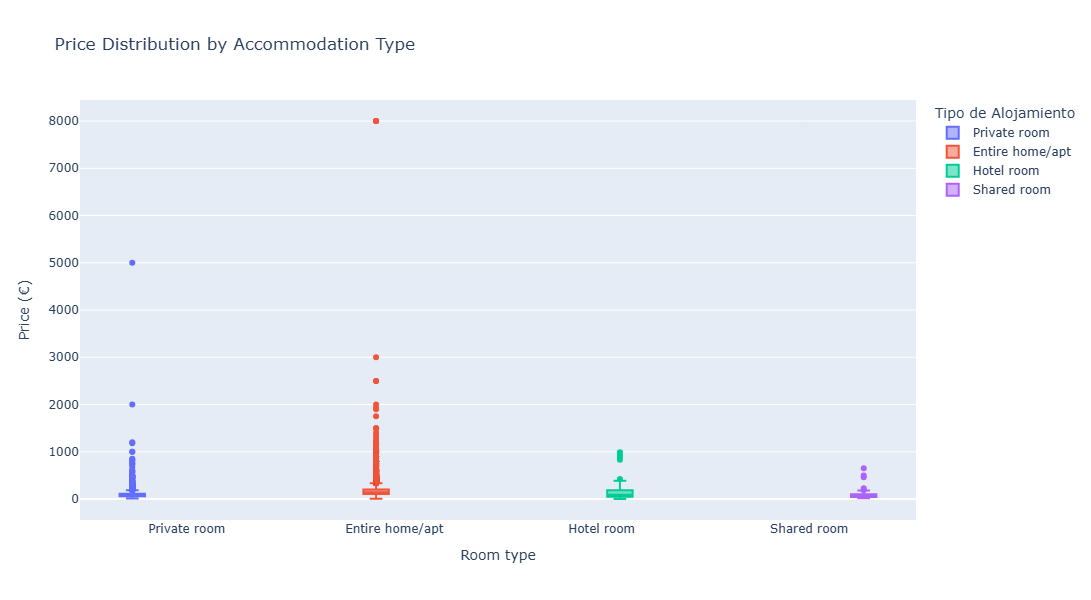

In [12]:
fig = px.box(data, x='room_type', y='price',
             title='Price Distribution by Accommodation Type',
             labels={'room_type': 'Tipo de Alojamiento', 'price': 'Precio (€)'},
             color='room_type',
             points='outliers')  

fig.update_layout(
    yaxis_title="Price (€)",
    xaxis_title="Room type",
    boxmode='group',
    height=600,
    width=900
)

fig.show()

Hotel rooms exhibit the highest standard deviations, IQRs, and coefficients of variation, indicating high relative variability relative to their mean. However, it is important to bear in mind the sample imbalance: hotel rooms account for only 0.7% of listings (n=124), while entire homes account for 78% (n=13,896). In small samples, measures of dispersion are more sensitive to outliers and less stable.
In contrast, entire homes and apartments have by far the widest absolute price range (€7,996), reflecting the true variability of this type of accommodation.

Considering the sample representativeness and the fact that the absolute range, the measure most directly linked to dispersion is clearly higher for entire homes, as shown in the box plot with outliers, the hypothesis is accepted. Although the hotels show greater relative dispersion, this evidence is less robust due to the small sample size.

#### 5. The listings with the best price scores are houses, apartments, and hotel rooms.

In [13]:
price_score = data.groupby('room_type')['review_scores_value'].agg(['mean', 'median', 'std']).reset_index()
price_score.columns = ['room_type', 'mean', 'median', 'std']
price_score

,room_type,mean,median,std
0,Entire home/apt,9.218186,9.0,0.826952
1,Hotel room,9.092784,9.0,0.646827
2,Private room,9.134770,9.0,0.905178
3,Shared room,9.113636,9.0,0.579330


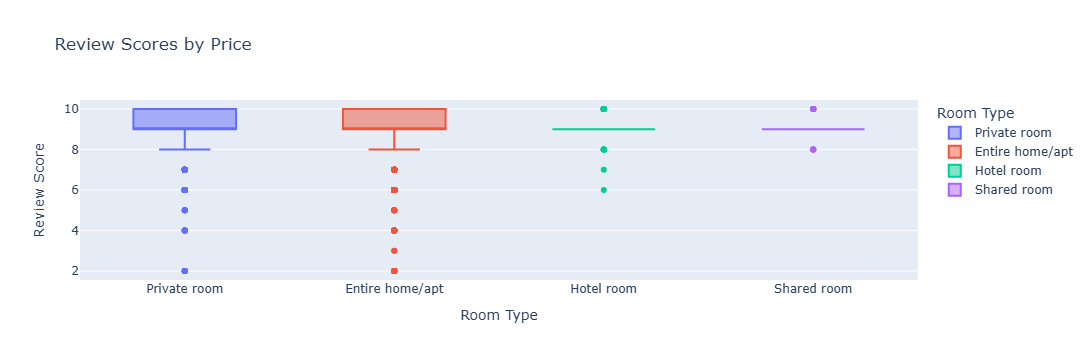

In [14]:
fig = px.box(data, x='room_type', y='review_scores_value',
             title='Review Scores by Price',
             labels={'room_type': 'Room Type', 'review_scores_value': 'Review Score'},
             color='room_type')
fig.show()

The hypothesis is partially accepted. The results show that houses and apartments have a higher average score in relation to price, but, as mentioned earlier, it is important to take into account the imbalance in the dataset.
Because the differences are minimal, it suggests that all types of housing offer a high and similar value for money, as can be seen in the median, which is the same for all four options.